# visualizer
visulazing and exploring our dataset just the way it is

In [22]:
!for /f "tokens=1* delims=:" %a in ('dir /b "..\dataset\CROHME_training_2011" ^| findstr /n "^"') do @if %a LEQ 10 echo %b

formulaire001-equation001.inkml
formulaire001-equation003.inkml
formulaire001-equation010.inkml
formulaire001-equation011.inkml
formulaire001-equation015.inkml
formulaire001-equation016.inkml
formulaire001-equation023.inkml
formulaire001-equation024.inkml
formulaire001-equation028.inkml
formulaire001-equation030.inkml


In [6]:
import xml.etree.ElementTree as ET

tree = ET.parse("../dataset/CROHME_training_2011/formulaire001-equation001.inkml")
root = tree.getroot()

In [8]:
root

<Element '{http://www.w3.org/2003/InkML}ink' at 0x000002357B0EACF0>

In [9]:
strokes = []
for trace in root.iter("{http://www.w3.org/2003/InkML}trace"):
    pts = []
    for pair in trace.text.strip().split(","):
        x, y = map(float, pair.split())
        pts.append((x, y))
    strokes.append(pts)

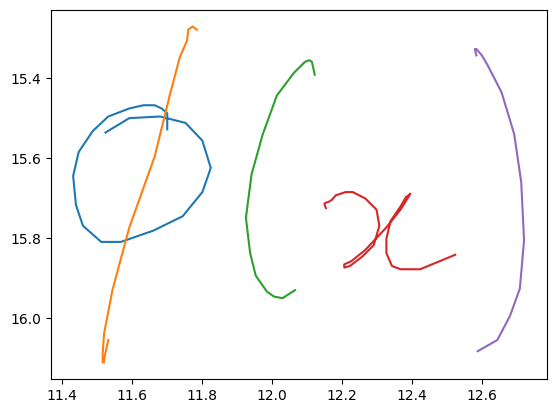

In [10]:
import matplotlib.pyplot as plt

for stroke in strokes:
    xs, ys = zip(*stroke)
    plt.plot(xs, ys)
plt.gca().invert_yaxis()
plt.show()

In [25]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

def inkplot(filename : str = None, filepath : str = None):
    ns = "{http://www.w3.org/2003/InkML}"
    tree = ET.parse(f"../dataset/CROHME_training_2011/{filename}") if (filename and not filepath) else ET.parse(filepath) 
    root = tree.getroot()
    strokes = []
    for trace in root.iter(f"{ns}trace"):
        raw = trace.text.strip()
        pts = []

        for pair in raw.split(","):
            x, y = map(float, pair.split())
            pts.append((x, y))
        strokes.append(pts)

    plt.figure(figsize=(5,5))
    for s in strokes:
        xs, ys = zip(*s)
        plt.plot(xs, ys, linewidth=1)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.show()

    return strokes

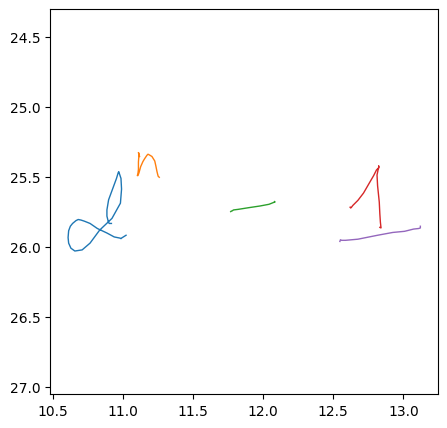

In [31]:
_ = inkplot("formulaire001-equation028.inkml")

model architecture we're gonna be using for detection and classification : **[YOLO](https://en.wikipedia.org/wiki/You_Only_Look_Once)**

* why yolo?

because yolo stands for "you only live once", and in this context- it's a super efficient way of doing both these tasks together, in one go. It also ensures the predicitions remain consistent with each other, and improve together when they do.

the yolo architecture is based on CNNs (obv) and are used in the real-world for object detection and related tasks. i wouldn't be suprised if tesla uses these for their CV tasks too!

it's written in: python

our application of this architecture will be fairly simple as compared to the kinds it's actaully designed for. 

and yeah, i would have to read about this architecture extensively before i go on designing my own 👍